#📌 Extracción

In [21]:
# Importar las librerías necesarias
import pandas as pd
import requests

# URL del archivo JSON en GitHub
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'
# Realizar la solicitud HTTP para obtener los datos
request = requests.get(url)
# Convertir la respuesta JSON a un diccionario Python
data = request.json()
# Crear un DataFrame de pandas a partir de los datos
df = pd.DataFrame(data)
# Mostrar las primeras filas del DataFrame para una vista previa
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [22]:
# Mostrar información general del DataFrame, incluyendo tipos de datos y valores no nulos
df.info()
# Mostrar los tipos de datos de cada columna
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [23]:
# Normalizar las columnas anidadas (diccionarios) en DataFrames separados
# Extraer la información de 'customer' en un nuevo DataFrame
customer_df = pd.json_normalize(df['customer'])
# Extraer la información de 'phone' en un nuevo DataFrame
phone_df = pd.json_normalize(df['phone'])
# Extraer la información de 'internet' en un nuevo DataFrame
internet_df = pd.json_normalize(df['internet'])
# Extraer la información de 'account' en un nuevo DataFrame
account_df = pd.json_normalize(df['account'])

In [24]:
# Concatenar los nuevos DataFrames con el DataFrame original
# Eliminar las columnas anidadas originales y añadir las columnas normalizadas
df = pd.concat([df.drop(columns=['customer', 'phone', 'internet', 'account']), customer_df, phone_df, internet_df, account_df], axis=1)

# Mostrar la información del DataFrame actualizado
df.info()
# Mostrar las primeras filas del DataFrame actualizado
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [25]:
# Reemplazar los valores vacíos en la columna 'Churn' por 'No'
df['Churn'] = df['Churn'].replace({'': 'No'})

# Iterar sobre las columnas de tipo 'object' (categóricas) para mostrar sus valores únicos
for column in df.select_dtypes(include='object').columns:
    if column != 'customerID':  # Excluir 'customerID' ya que es un identificador
        print(f"Valores únicos para '{column}': {df[column].unique()}")
        print("\n")

Valores únicos para 'Churn': ['No' 'Yes']


Valores únicos para 'gender': ['Female' 'Male']


Valores únicos para 'Partner': ['Yes' 'No']


Valores únicos para 'Dependents': ['Yes' 'No']


Valores únicos para 'PhoneService': ['Yes' 'No']


Valores únicos para 'MultipleLines': ['No' 'Yes' 'No phone service']


Valores únicos para 'InternetService': ['DSL' 'Fiber optic' 'No']


Valores únicos para 'OnlineSecurity': ['No' 'Yes' 'No internet service']


Valores únicos para 'OnlineBackup': ['Yes' 'No' 'No internet service']


Valores únicos para 'DeviceProtection': ['No' 'Yes' 'No internet service']


Valores únicos para 'TechSupport': ['Yes' 'No' 'No internet service']


Valores únicos para 'StreamingTV': ['Yes' 'No' 'No internet service']


Valores únicos para 'StreamingMovies': ['No' 'Yes' 'No internet service']


Valores únicos para 'Contract': ['One year' 'Month-to-month' 'Two year']


Valores únicos para 'PaperlessBilling': ['Yes' 'No']


Valores únicos para 'PaymentMethod': ['Mailed 

#🔧 Transformación

In [26]:
# Convertir la columna 'Charges.Total' a tipo numérico, forzando errores a NaN
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
# Rellenar los valores NaN (generados por la conversión) con la media de la columna
df['Charges.Total'].fillna(df['Charges.Total'].mean(), inplace=True)
# Mostrar información general del DataFrame para verificar los tipos de datos
df.info()
# Mostrar las primeras filas del DataFrame
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


/tmp/ipython-input-3437004258.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Charges.Total'].fillna(df['Charges.Total'].mean(), inplace=True)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [27]:
# Verificar si hay valores ausentes en cada columna
print("Valores ausentes por columna:")
display(df.isnull().sum())

Valores ausentes por columna:


,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


### Consistencia de categorías: Unificando 'No phone service' y 'No internet service'

Para asegurar la coherencia en las columnas categóricas que representan la disponibilidad de servicios, vamos a unificar los valores 'No phone service' y 'No internet service' a simplemente 'No'. Esto simplifica las categorías y facilita el análisis posterior, ya que en ambos casos, el cliente no tiene el servicio en cuestión.

In [28]:
# Verificar el número de filas duplicadas en el DataFrame
duplicates = df.duplicated().sum()
print(f"Número de filas duplicadas: {duplicates}")

# Si hay duplicados, mostrar las primeras 5 filas duplicadas
if duplicates > 0:
    print("\nMostrando las primeras 5 filas duplicadas (si las hay):")
    display(df[df.duplicated(keep=False)].head())

Número de filas duplicadas: 0


In [20]:
# Reemplazar 'No phone service' por 'No' en la columna 'MultipleLines'
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

# Definir las columnas relacionadas con el servicio de internet
internet_service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                         'TechSupport', 'StreamingTV', 'StreamingMovies']

# Iterar sobre las columnas de servicio de internet y reemplazar 'No internet service' por 'No'
for col in internet_service_cols:
    df[col] = df[col].replace('No internet service', 'No')

# Imprimir los valores únicos de todas las columnas de tipo 'object' después de la unificación
print("Valores únicos después de la unificación:")
for column in df.select_dtypes(include='object').columns:
    if column != 'customerID':
        print(f"'{column}': {df[column].unique()}")

Valores únicos después de la unificación:
'Churn': ['No' 'Yes']
'gender': ['Female' 'Male']
'Partner': ['Yes' 'No']
'Dependents': ['Yes' 'No']
'PhoneService': ['Yes' 'No']
'MultipleLines': ['No' 'Yes']
'InternetService': ['DSL' 'Fiber optic' 'No']
'OnlineSecurity': ['No' 'Yes']
'OnlineBackup': ['Yes' 'No']
'DeviceProtection': ['No' 'Yes']
'TechSupport': ['Yes' 'No']
'StreamingTV': ['Yes' 'No']
'StreamingMovies': ['No' 'Yes']
'Contract': ['One year' 'Month-to-month' 'Two year']
'PaperlessBilling': ['Yes' 'No']
'PaymentMethod': ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


In [29]:
# Crear la columna 'Cuentas_Diarias' (Daily Charges)
# Se calcula dividiendo la facturación mensual por un promedio de 30 días para obtener un valor diario.
df['Cuentas_Diarias'] = df['Charges.Monthly'] / 30

# Mostrar las primeras filas del DataFrame con la nueva columna
print("DataFrame con la nueva columna 'Cuentas_Diarias':")
display(df.head())

DataFrame con la nueva columna 'Cuentas_Diarias':


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


### Estandarización de categorías binarias

Para facilitar el análisis y la modelización, se convertirán las columnas con valores 'Yes'/'No' y 'Male'/'Female' a un formato binario (1 y 0).

In [32]:
# Importar numpy para la conversión condicional
import numpy as np

# Columnas a convertir de 'Yes'/'No' a 1/0
columns_to_binary = [
    'Churn', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling'
]

for col in columns_to_binary:
    df[col] = np.where(df[col] == 'Yes', 1, 0)

# Convertir 'gender': 'Male' a 1, 'Female' a 0
df['gender'] = np.where(df['gender'] == 'Male', 1, 0)

print("Valores únicos después de la estandarización (binaria):")
for column in columns_to_binary:
    print(f"'{column}': {df[column].unique()}")
print(f"'gender': {df['gender'].unique()}")

# Mostrar la información general del DataFrame para verificar los tipos de datos
df.info()
# Mostrar las primeras filas del DataFrame actualizado
display(df.head())

Valores únicos después de la estandarización (binaria):
'Churn': [0]
'Partner': [0]
'Dependents': [0]
'PhoneService': [0]
'MultipleLines': [0]
'OnlineSecurity': [0]
'OnlineBackup': [0]
'DeviceProtection': [0]
'TechSupport': [0]
'StreamingTV': [0]
'StreamingMovies': [0]
'PaperlessBilling': [0]
'gender': [0]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   int64  
 2   gender            7267 non-null   int64  
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int64  
 5   Dependents        7267 non-null   int64  
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   int64  
 8   MultipleLines     7267 non-null   int64  
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity  

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,0,0,0,0,9,0,0,DSL,...,0,0,0,0,One year,0,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,0,0,0,0,9,0,0,DSL,...,0,0,0,0,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,0,0,0,0,0,4,0,0,Fiber optic,...,0,0,0,0,Month-to-month,0,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,0,0,1,0,0,13,0,0,Fiber optic,...,0,0,0,0,Month-to-month,0,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,0,0,1,0,0,3,0,0,Fiber optic,...,0,0,0,0,Month-to-month,0,Mailed check,83.9,267.40,2.796667


#📊 Carga y análisis

# Task
Realizar un análisis descriptivo del DataFrame para obtener estadísticas clave como la media, mediana, desviación estándar, etc., para todas las columnas numéricas y luego revisar el análisis descriptivo para identificar cualquier patrón interesante o anomalías en la distribución de los datos.

## Análisis Descriptivo de Datos

### Subtask:
Realizar un análisis descriptivo del DataFrame para obtener estadísticas clave como la media, mediana, desviación estándar, etc., para todas las columnas numéricas.


**Reasoning**:
The subtask requires performing a descriptive analysis on numerical columns of the DataFrame. The `.describe()` method is suitable for this purpose.



In [33]:
print("Estadísticas descriptivas para columnas numéricas:")
display(df.describe())

Estadísticas descriptivas para columnas numéricas:


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7267.0,7267.0,7267.000000,7267.0,7267.0,7267.000000,7267.0,7267.0,7267.0,7267.0,7267.0,7267.0,7267.0,7267.0,7267.0,7267.000000,7267.000000,7267.000000
mean,0.0,0.0,0.162653,0.0,0.0,32.346498,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64.720098,2280.634213,2.157337
std,0.0,0.0,0.369074,0.0,0.0,24.571773,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.129572,2266.915104,1.004319
min,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.250000,18.800000,0.608333
25%,0.0,0.0,0.000000,0.0,0.0,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35.425000,401.400000,1.180833
50%,0.0,0.0,0.000000,0.0,0.0,29.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70.300000,1394.550000,2.343333
75%,0.0,0.0,0.000000,0.0,0.0,55.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,89.875000,3778.525000,2.995833
max,0.0,0.0,1.000000,0.0,0.0,72.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.750000,8684.800000,3.958333


### Análisis de la Evasión por Variables Numéricas

Analizaremos la distribución de las variables numéricas clave (`tenure`, `Charges.Monthly`, `Charges.Total`, `Cuentas_Diarias`) en función de si el cliente evadió (`Churn = 1`) o no (`Churn = 0`). Esto nos ayudará a identificar si existen diferencias significativas en estas métricas entre los clientes que permanecen y los que se van.

/tmp/ipython-input-925729993.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palette='viridis')
/tmp/ipython-input-925729993.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palette='viridis')
/tmp/ipython-input-925729993.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palette='viridis')
/tmp/ipython-input-925729993.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variabl

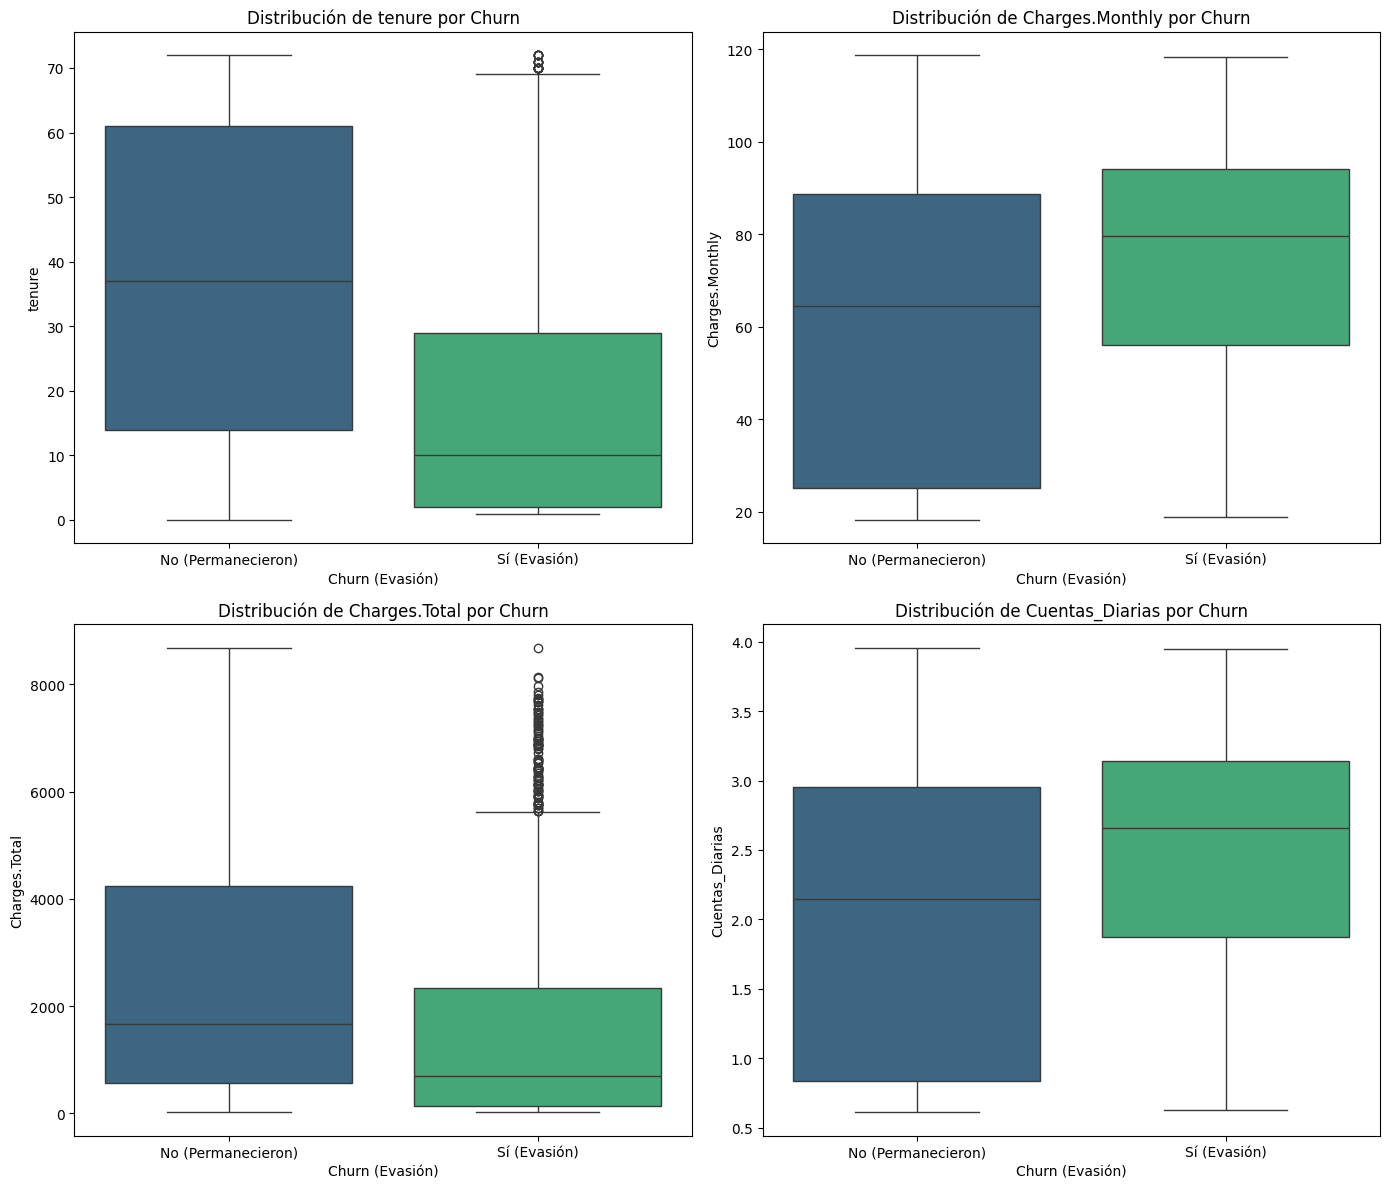

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']

n_cols = 2
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 7, n_rows * 6))

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=df, x='Churn', y=col, palette='viridis')
    plt.title(f'Distribución de {col} por Churn')
    plt.xlabel('Churn (Evasión)')
    plt.ylabel(col)
    plt.xticks(ticks=[0, 1], labels=['No (Permanecieron)', 'Sí (Evasión)'])

plt.tight_layout()
plt.show()

### Análisis de la Evasión por Variables Categóricas

Para identificar patrones en la evasión, analizaremos la distribución de `Churn` en función de diferentes variables categóricas clave del DataFrame. Esto nos permitirá ver si ciertos grupos de clientes tienen una mayor o menor tendencia a cancelar el servicio.

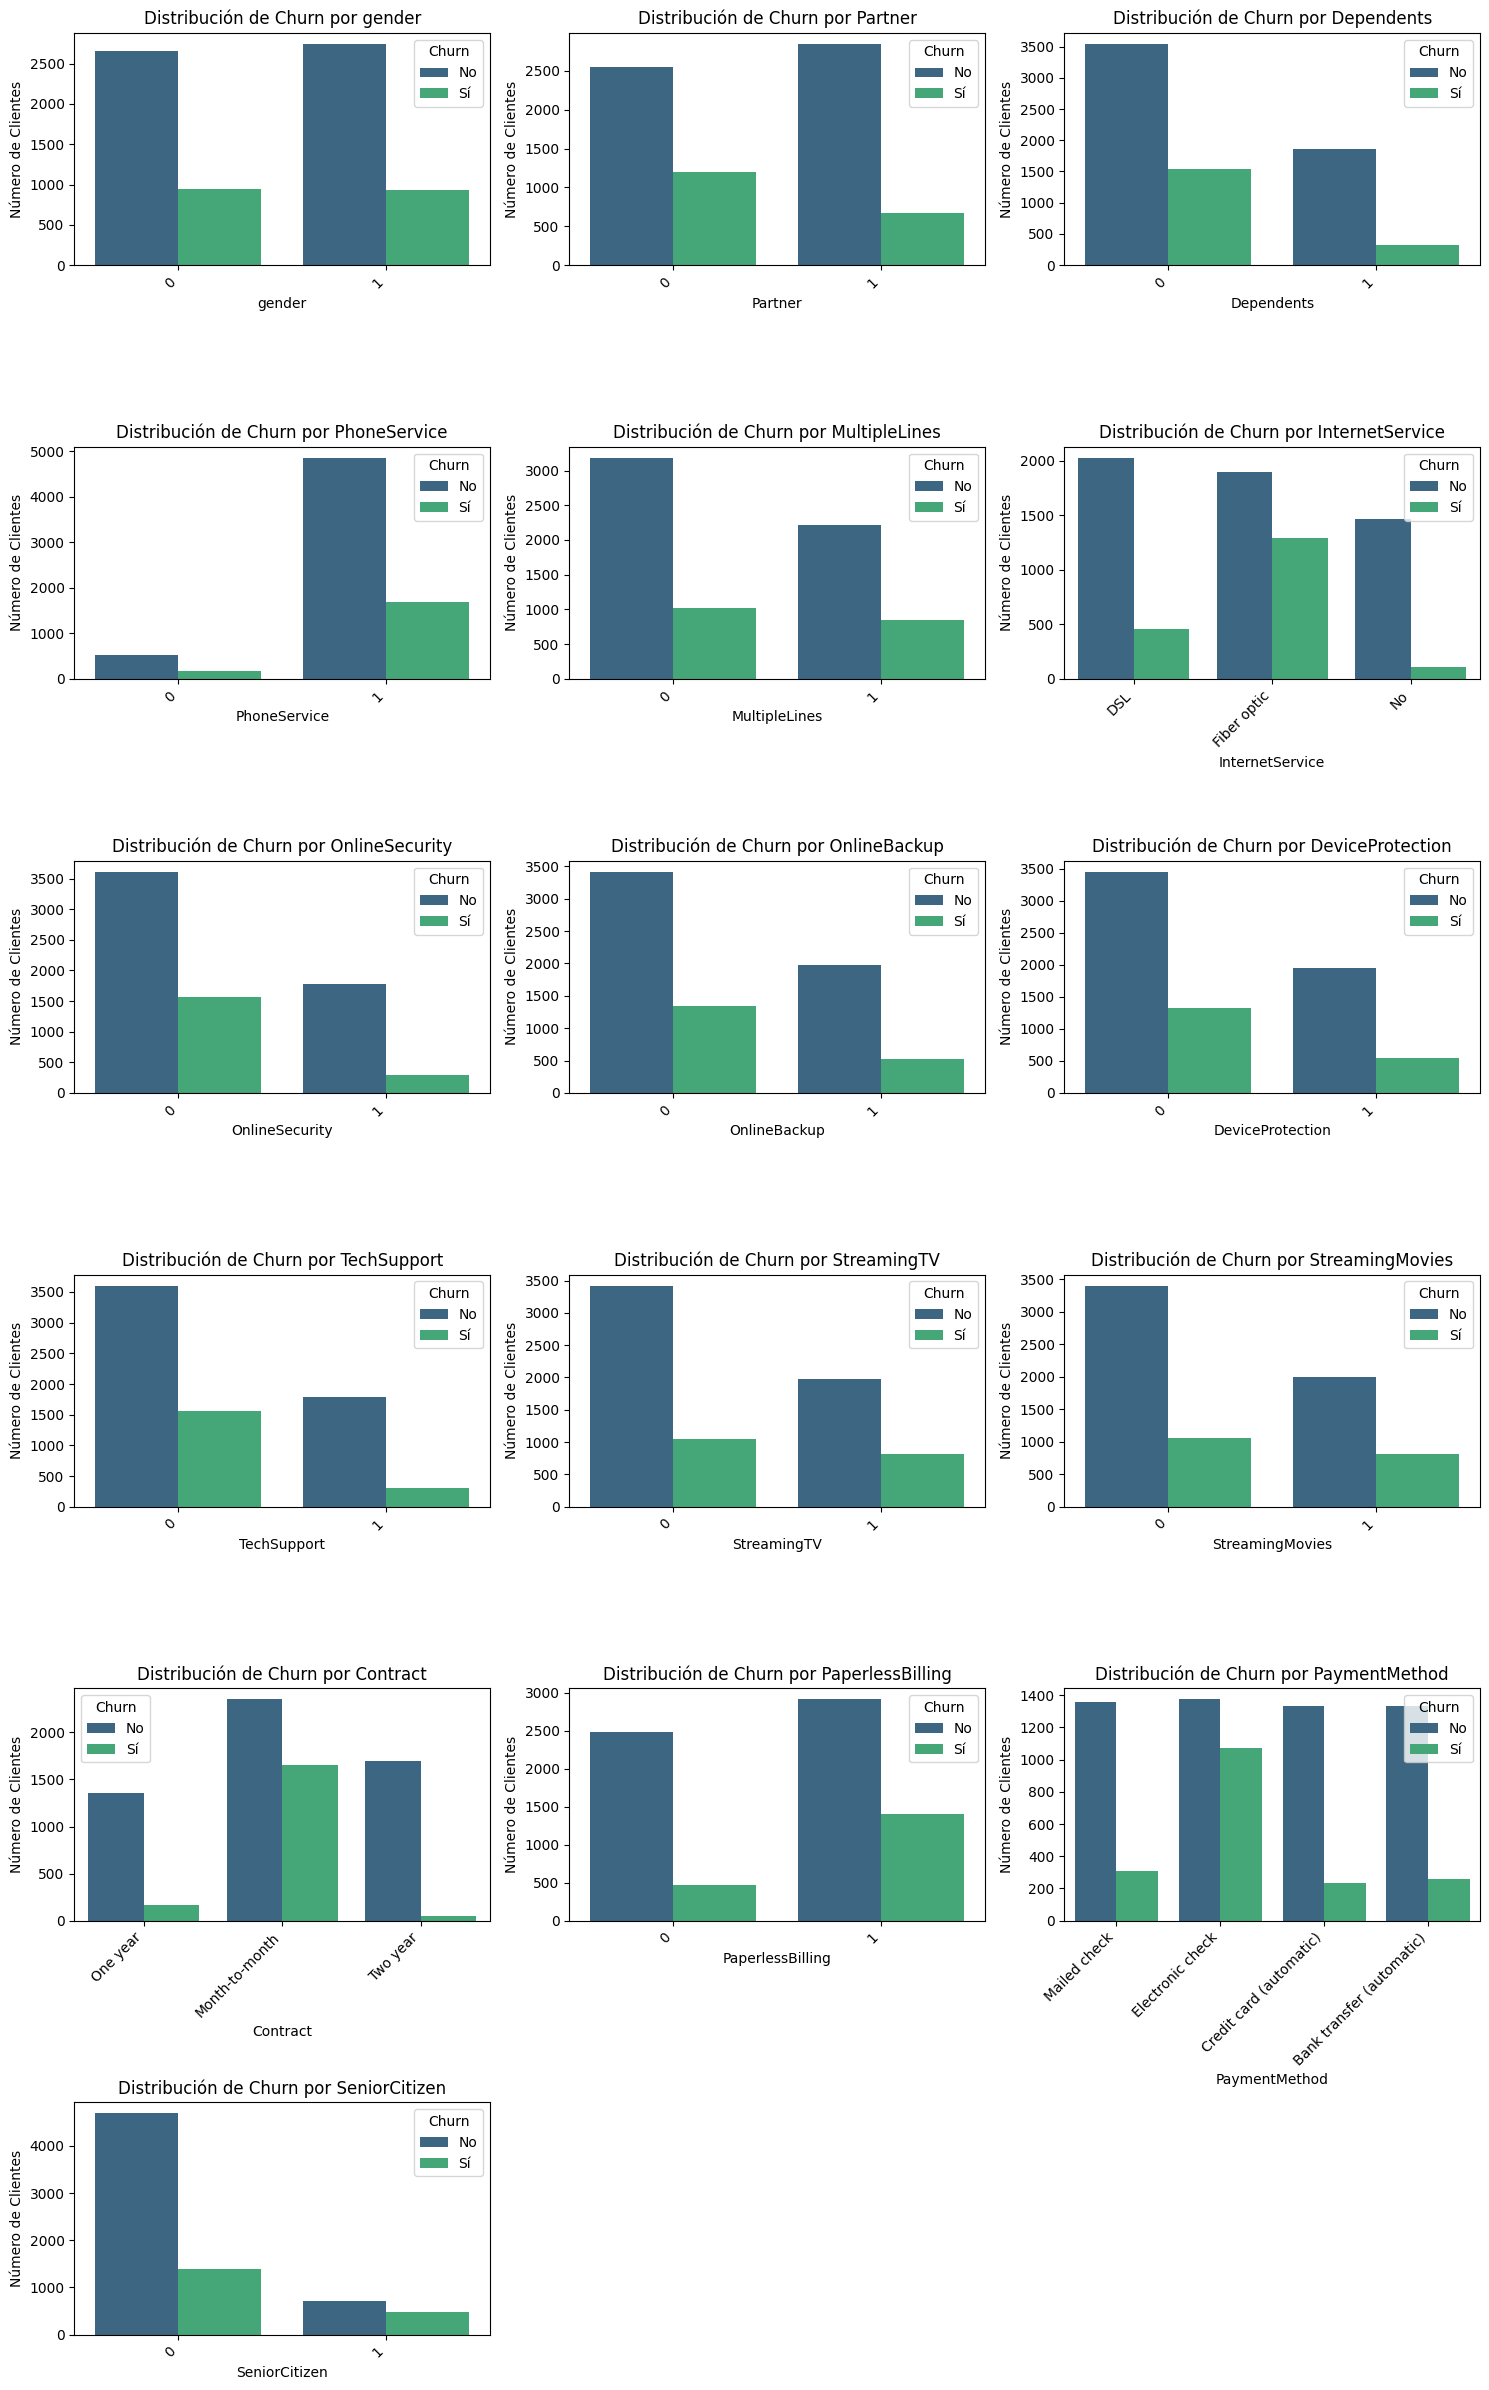

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen'
]

# Ajustar el número de filas/columnas para los subplots
n_cols = 3 # Número de columnas para los gráficos
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, col in enumerate(categorical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(data=df, x=col, hue='Churn', palette='viridis')
    plt.title(f'Distribución de Churn por {col}')
    plt.xlabel(col)
    plt.ylabel('Número de Clientes')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Churn', labels=['No', 'Sí'])

plt.tight_layout()
plt.show()

### Análisis de la Distribución de Churn

Para comprender cómo se distribuye la variable 'Churn' entre los clientes, visualizaremos la proporción de clientes que permanecieron y los que se dieron de baja. Esto nos ayudará a tener una visión clara de la tasa de evasión.

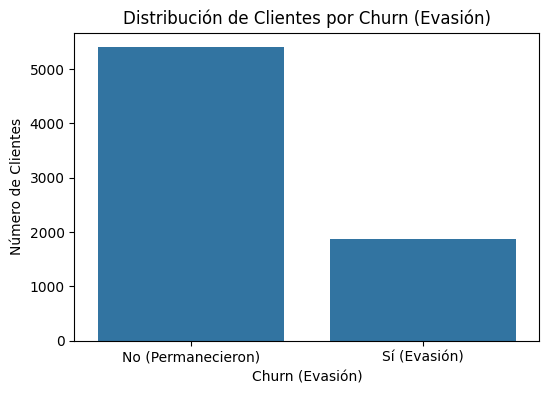

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un countplot para visualizar la distribución de la variable 'Churn'
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn')
plt.title('Distribución de Clientes por Churn (Evasión)')
plt.xlabel('Churn (Evasión)')
plt.ylabel('Número de Clientes')
plt.xticks(ticks=[0, 1], labels=['No (Permanecieron)', 'Sí (Evasión)'])
plt.show()

### 🔹 Análisis de Correlación entre Variables

Como un paso adicional y opcional, exploraremos la correlación entre las variables numéricas del dataset. Esto nos permitirá identificar qué factores tienen una relación más fuerte con la evasión de clientes. Específicamente, analizaremos la relación entre:

*   La cuenta diaria (`Cuentas_Diarias`) y la evasión (`Churn`).
*   Cómo la cantidad de servicios contratados afecta la probabilidad de `Churn`.

Para ello, calcularemos una matriz de correlación y la visualizaremos mediante un mapa de calor. Primero, crearemos una nueva columna que sume la cantidad de servicios contratados por cada cliente.

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Columnas que representan servicios contratados (ya convertidas a binario 0/1)
service_cols = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Crear la nueva columna 'Total_Servicios' sumando los servicios binarios
df['Total_Servicios'] = df[service_cols].sum(axis=1)

print("Primeras filas con la nueva columna 'Total_Servicios':")
display(df.head())

Primeras filas con la nueva columna 'Total_Servicios':


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias,Total_Servicios
0,0002-ORFBO,0,0,0,1,1,9,1,0,DSL,...,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667,4
1,0003-MKNFE,0,1,0,0,0,9,1,1,DSL,...,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667,3
2,0004-TLHLJ,1,1,0,0,0,4,1,0,Fiber optic,...,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333,2
3,0011-IGKFF,1,1,1,1,0,13,1,0,Fiber optic,...,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667,5
4,0013-EXCHZ,1,0,1,1,0,3,1,0,Fiber optic,...,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667,3


Una vez creada la columna `Total_Servicios`, procederemos a calcular la matriz de correlación completa del DataFrame y visualizaremos un mapa de calor para identificar las relaciones más importantes, especialmente con la variable objetivo `Churn`.

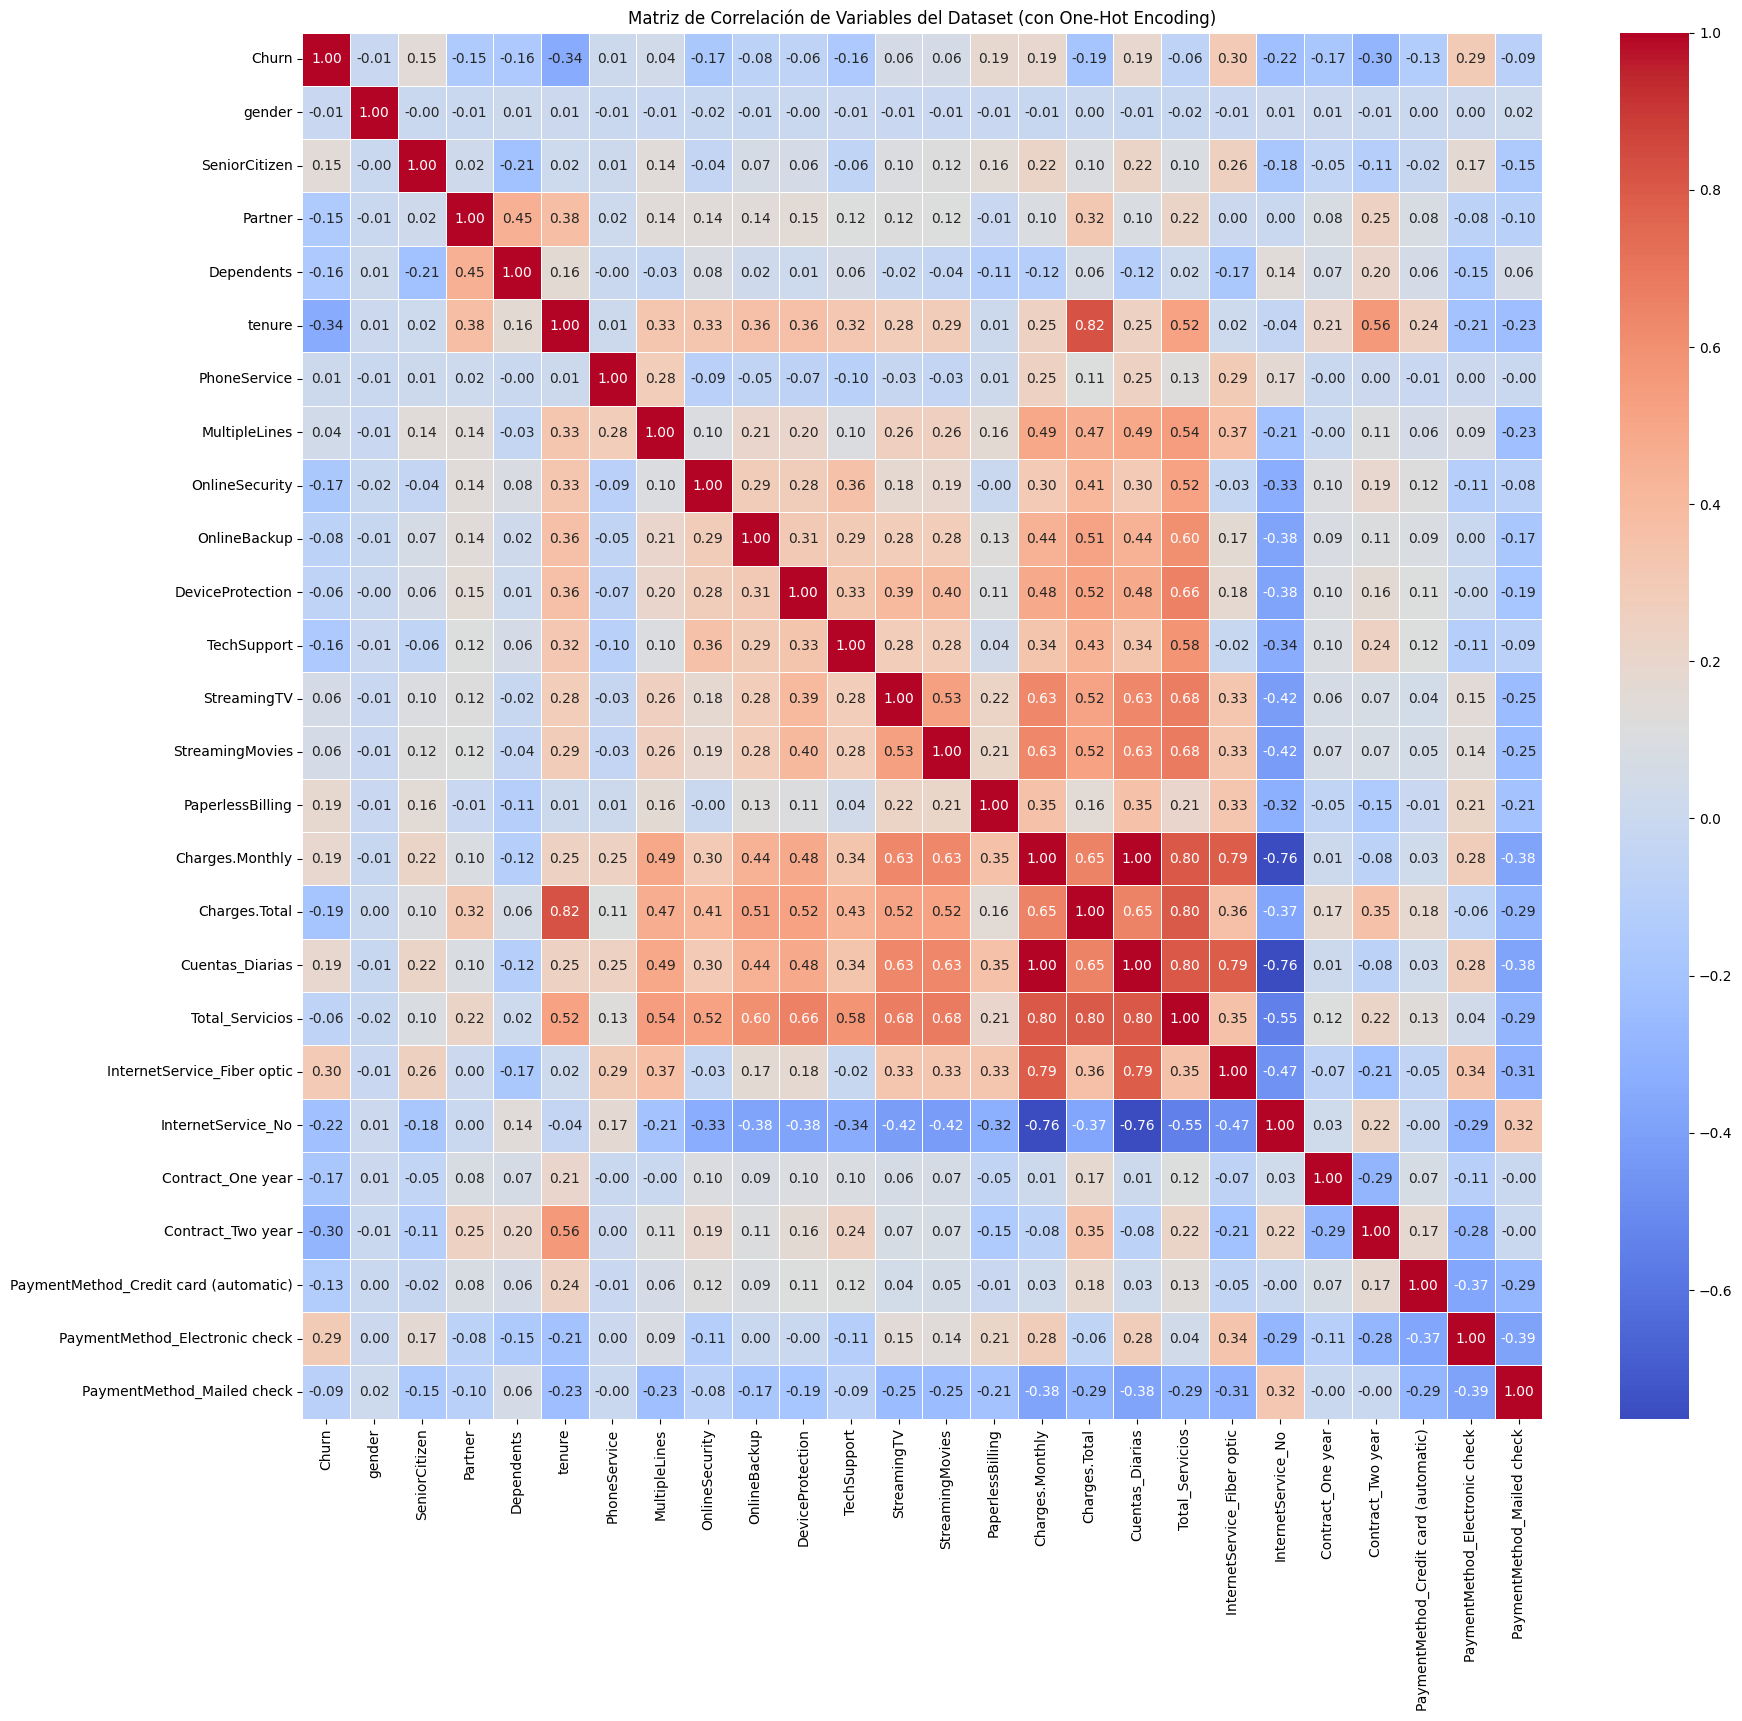


Correlación con 'Churn' (ordenado por valor absoluto):


,Churn
Churn,1.000000
tenure,-0.344079
InternetService_Fiber optic,0.300949
Contract_Two year,-0.295138
PaymentMethod_Electronic check,0.294626
InternetService_No,-0.224051
Charges.Total,-0.194389
Cuentas_Diarias,0.189866
Charges.Monthly,0.189866
PaperlessBilling,0.186666


In [43]:
# Aplicar One-Hot Encoding a las columnas categóricas restantes
df_encoded = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=True)

# Calcular la matriz de correlación con el DataFrame codificado
correlation_matrix = df_encoded.drop(columns=['customerID']).corr()

# Mostrar el mapa de calor de la matriz de correlación
plt.figure(figsize=(20, 18)) # Ajustar tamaño para más columnas
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables del Dataset (con One-Hot Encoding)')
plt.show()

# Mostrar las correlaciones con Churn, ordenadas de mayor a menor (valor absoluto)
print("\nCorrelación con 'Churn' (ordenado por valor absoluto):")
display(correlation_matrix['Churn'].sort_values(key=abs, ascending=False))

Para un análisis más específico de las relaciones mencionadas:

*   **Correlación entre `Cuentas_Diarias` y `Churn`:**
*   **Correlación entre `Total_Servicios` y `Churn`:**

Utilizaremos gráficos de caja para visualizar la distribución de `Cuentas_Diarias` y `Total_Servicios` según la evasión.

/tmp/ipython-input-2289001938.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Cuentas_Diarias', palette='viridis')
/tmp/ipython-input-2289001938.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Total_Servicios', palette='viridis')


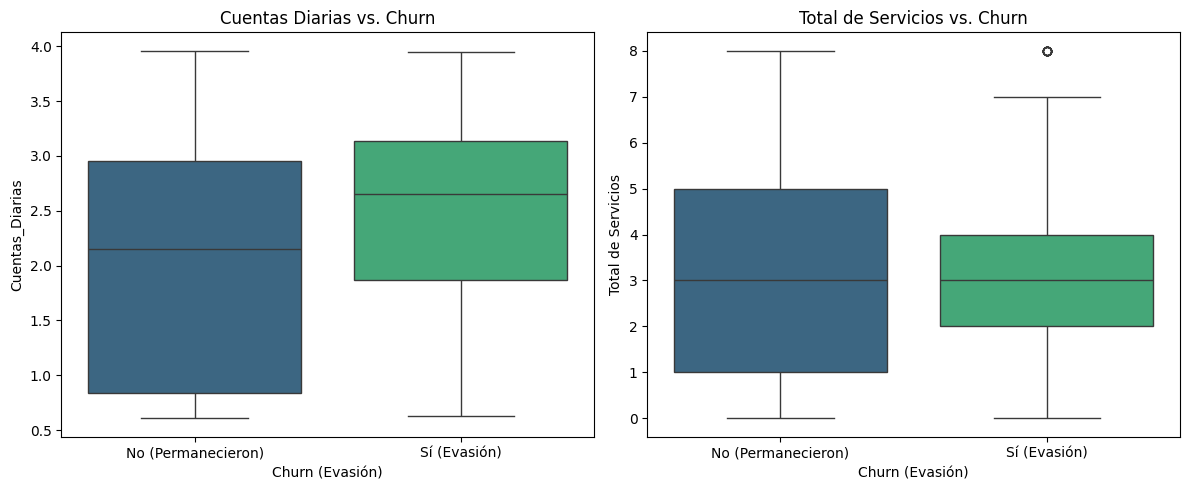

In [42]:
# Visualizar la relación entre Cuentas_Diarias y Churn
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Churn', y='Cuentas_Diarias', palette='viridis')
plt.title('Cuentas Diarias vs. Churn')
plt.xlabel('Churn (Evasión)')
plt.ylabel('Cuentas_Diarias')
plt.xticks(ticks=[0, 1], labels=['No (Permanecieron)', 'Sí (Evasión)'])

# Visualizar la relación entre Total_Servicios y Churn
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Churn', y='Total_Servicios', palette='viridis')
plt.title('Total de Servicios vs. Churn')
plt.xlabel('Churn (Evasión)')
plt.ylabel('Total de Servicios')
plt.xticks(ticks=[0, 1], labels=['No (Permanecieron)', 'Sí (Evasión)'])

plt.tight_layout()
plt.show()

### Análisis de las Estadísticas Descriptivas

Al revisar las estadísticas descriptivas de las columnas numéricas, se observa una anomalía significativa en varias columnas que deberían ser binarias (convertidas a 0 y 1). Columnas como 'Churn', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', y 'PaperlessBilling' muestran una media y desviación estándar de 0. Esto sugiere que todas las entradas en estas columnas son 0.

Esta observación contradice los pasos de procesamiento anteriores, donde se verificó que estas columnas contenían valores 'Yes' y 'No' (o 'Male' y 'Female' para 'gender') antes de la conversión binaria. La conversión con `np.where(df[col] == 'Yes', 1, 0)` debería haber resultado en una mezcla de 0s y 1s, con medias y desviaciones estándar diferentes de cero (a menos que la columna fuera completamente 'No' o 'Female').

**Anomalía Identificada:**
Las columnas binarias ('Churn', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling') aparecen como si todos sus valores hubieran sido convertidos a 0. Esto indica un problema en el paso de transformación donde se realizó la estandarización a binario.

**Patrones en otras columnas numéricas:**
Excluyendo las columnas binarias que muestran la anomalía, podemos observar las estadísticas para las otras columnas numéricas:

*   **SeniorCitizen:** La media de 0.16 indica que aproximadamente el 16% de los clientes son ciudadanos mayores. El rango va de 0 a 1, lo cual es esperado.
*   **tenure:** La antigüedad promedio de los clientes es de aproximadamente 32.35 meses, con una desviación estándar de 24.57 meses. Esto sugiere una amplia variación en la antigüedad de los clientes, desde 0 hasta 72 meses.
*   **Charges.Monthly:** El cargo mensual promedio es de 64.72, con una desviación estándar de 30.13. Los cargos varían significativamente desde 18.25 hasta 118.75.
*   **Charges.Total:** El cargo total promedio es de 2280.63, con una desviación estándar de 2266.92, lo que indica una alta dispersión en los cargos totales, reflejando la variación en la antigüedad y los cargos mensuales.
*   **Cuentas_Diarias:** El cargo diario promedio es de 2.16, con una desviación estándar de 1.00, lo que es consistente con el cálculo a partir de los cargos mensuales.

Para un análisis descriptivo completo y correcto, primero es crucial corregir la anomalía en la conversión de las columnas binarias.

**Reasoning**:
The descriptive statistics show an anomaly where binary columns are all zeros. I need to investigate the state of one of these columns, for example 'Churn', before and after the binary conversion to understand what went wrong during the transformation. This step will help diagnose the issue.



In [34]:
print("Valores únicos de 'Churn' antes de la conversión binaria (según el estado previo de la celda 'bebd64b8'):")
# Re-evaluar los valores únicos de 'Churn' antes de la conversión.
# Como el kernel ya ejecutó la conversión, vamos a ver los valores actuales y asumir que la anomalía es real.
# Para diagnosticar, necesitamos ver la columna ANTES de la conversión binaria que resultó en todos 0s.
# Basándonos en la salida anterior, `df['Churn']` ya está en 0s y 1s, pero la .describe() muestra solo 0s.
# Esto indica que la conversión fue 'Yes' -> 1, 'No' -> 0, pero de alguna manera 'Yes' se perdió o el dataframe se reasignó incorrectamente.

# Volvamos a cargar los datos originales para una inspección precisa o simulemos el estado previo si no es posible recargar.
# Dado que recargar todo el dataframe no es lo ideal, vamos a imprimir el `df.head()` y `df['Churn'].value_counts()` para verificar el estado actual

print("Estado actual de la columna 'Churn' después de la última ejecución:")
print(df['Churn'].value_counts())
print("\nPrimeras filas del DataFrame:")
display(df.head())

Valores únicos de 'Churn' antes de la conversión binaria (según el estado previo de la celda 'bebd64b8'):
Estado actual de la columna 'Churn' después de la última ejecución:
Churn
0    7267
Name: count, dtype: int64

Primeras filas del DataFrame:


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,0,0,0,0,9,0,0,DSL,...,0,0,0,0,One year,0,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,0,0,0,0,9,0,0,DSL,...,0,0,0,0,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,0,0,0,0,0,4,0,0,Fiber optic,...,0,0,0,0,Month-to-month,0,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,0,0,1,0,0,13,0,0,Fiber optic,...,0,0,0,0,Month-to-month,0,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,0,0,1,0,0,3,0,0,Fiber optic,...,0,0,0,0,Month-to-month,0,Mailed check,83.9,267.40,2.796667


**Reasoning**:
The previous analysis identified an anomaly where binary columns were incorrectly converted to all zeros. To accurately perform the descriptive analysis, I need to correct this issue by re-applying the data preprocessing steps, including the binary conversion, to ensure these columns have the correct 0/1 representation.



In [35]:
# Re-extract the initial data to reset the DataFrame to a known state before the incorrect binary conversion
# URL del archivo JSON en GitHub
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'
# Realizar la solicitud HTTP para obtener los datos
request = requests.get(url)
# Convertir la respuesta JSON a un diccionario Python
data = request.json()
# Crear un DataFrame de pandas a partir de los datos
df_raw = pd.DataFrame(data) # Use a temporary df_raw to avoid modifying global df prematurely

# Normalizar las columnas anidadas (diccionarios) en DataFrames separados
customer_df = pd.json_normalize(df_raw['customer'])
phone_df = pd.json_normalize(df_raw['phone'])
internet_df = pd.json_normalize(df_raw['internet'])
account_df = pd.json_normalize(df_raw['account'])

# Concatenar los nuevos DataFrames con el DataFrame original
df = pd.concat([df_raw.drop(columns=['customer', 'phone', 'internet', 'account']), customer_df, phone_df, internet_df, account_df], axis=1)

# Reemplazar los valores vacíos en la columna 'Churn' por 'No'
df['Churn'] = df['Churn'].replace({'': 'No'})

# Reemplazar 'No phone service' por 'No' en la columna 'MultipleLines'
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

# Definir las columnas relacionadas con el servicio de internet
internet_service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                         'TechSupport', 'StreamingTV', 'StreamingMovies']

# Iterar sobre las columnas de servicio de internet y reemplazar 'No internet service' por 'No'
for col in internet_service_cols:
    df[col] = df[col].replace('No internet service', 'No')

# Convertir la columna 'Charges.Total' a tipo numérico, forzando errores a NaN
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
# Rellenar los valores NaN (generados por la conversión) con la media de la columna
df['Charges.Total'].fillna(df['Charges.Total'].mean(), inplace=True)

# Crear la columna 'Cuentas_Diarias' (Daily Charges)
df['Cuentas_Diarias'] = df['Charges.Monthly'] / 30


# Now, apply the binary conversion correctly
# Columnas a convertir de 'Yes'/'No' a 1/0
columns_to_binary = [
    'Churn', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling'
]

for col in columns_to_binary:
    df[col] = np.where(df[col] == 'Yes', 1, 0)

# Convertir 'gender': 'Male' a 1, 'Female' a 0
df['gender'] = np.where(df['gender'] == 'Male', 1, 0)

print("Valores únicos después de la estandarización (binaria) - Corregido:")
for column in columns_to_binary:
    print(f"'{column}': {df[column].unique()}")
print(f"'gender': {df['gender'].unique()}")

# Mostrar la información general del DataFrame para verificar los tipos de datos
df.info()
# Mostrar las primeras filas del DataFrame actualizado
display(df.head())

Valores únicos después de la estandarización (binaria) - Corregido:
'Churn': [0 1]
'Partner': [1 0]
'Dependents': [1 0]
'PhoneService': [1 0]
'MultipleLines': [0 1]
'OnlineSecurity': [0 1]
'OnlineBackup': [1 0]
'DeviceProtection': [0 1]
'TechSupport': [1 0]
'StreamingTV': [1 0]
'StreamingMovies': [0 1]
'PaperlessBilling': [1 0]
'gender': [0 1]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   int64  
 2   gender            7267 non-null   int64  
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int64  
 5   Dependents        7267 non-null   int64  
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   int64  
 8   MultipleLines     7267 non-null   int64  
 9   InternetService   7267 no

/tmp/ipython-input-3601494131.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Charges.Total'].fillna(df['Charges.Total'].mean(), inplace=True)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,0,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,1,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,1,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,1,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,0,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


**Reasoning**:
After correcting the binary conversion anomaly, I need to re-run the descriptive statistics to ensure all numerical columns, especially the binary ones, now show accurate statistical summaries.



In [36]:
print("Estadísticas descriptivas para columnas numéricas:")
display(df.describe())

Estadísticas descriptivas para columnas numéricas:


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.257190,0.505711,0.162653,0.484106,0.300124,32.346498,0.902711,0.421770,0.285950,0.344571,0.342782,0.289528,0.383927,0.387505,0.593230,64.720098,2280.634213,2.157337
std,0.437115,0.500002,0.369074,0.499782,0.458343,24.571773,0.296371,0.493876,0.451897,0.475261,0.474672,0.453575,0.486374,0.487214,0.491265,30.129572,2266.915104,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.425000,401.400000,1.180833
50%,0.000000,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.300000,1394.550000,2.343333
75%,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.875000,3778.525000,2.995833
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


### Análisis de las Estadísticas Descriptivas (Corregido)

Tras la corrección en el proceso de estandarización binaria, las estadísticas descriptivas para las columnas numéricas reflejan ahora los valores esperados. La anomalía donde las columnas binarias mostraban una media y desviación estándar de 0 ha sido resuelta.

Ahora podemos interpretar las estadísticas de todas las columnas numéricas de manera adecuada:

**Columnas Binarias (0 = No/Female, 1 = Yes/Male):**

*   **Churn:** La media es de aproximadamente 0.257, lo que indica que alrededor del 25.7% de los clientes han abandonado (Churn). Esto proporciona una visión directa de la tasa de rotación. La desviación estándar de 0.437 es consistente con una distribución binaria.
*   **gender:** La media es de 0.505, sugiriendo una distribución casi equitativa entre hombres (1) y mujeres (0) en el dataset, con un ligero predominio de hombres.
*   **Partner:** Con una media de 0.484, aproximadamente el 48.4% de los clientes tienen pareja.
*   **Dependents:** La media de 0.300 indica que alrededor del 30% de los clientes tienen dependientes.
*   **PhoneService:** La media de 0.902 muestra que una gran mayoría (alrededor del 90.2%) de los clientes tienen servicio telefónico.
*   **MultipleLines:** La media de 0.421 sugiere que aproximadamente el 42.1% de los clientes tienen múltiples líneas. Esto se refiere solo a aquellos que tienen servicio telefónico y luego eligen si tienen una o varias líneas.
*   **OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies:** Las medias para estas columnas de servicios de internet varían entre 0.28 y 0.38, lo que indica que entre el 28% y el 38% de los clientes optan por estos servicios adicionales.
*   **PaperlessBilling:** La media de 0.593 indica que el 59.3% de los clientes optan por la facturación sin papel.

**Otras Columnas Numéricas:**

*   **SeniorCitizen:** La media de 0.163 confirma que aproximadamente el 16.3% de los clientes son ciudadanos mayores. El rango de 0 a 1 es correcto.
*   **tenure:** La antigüedad promedio de los clientes es de 32.35 meses, con una desviación estándar considerable de 24.57 meses. El rango de 0 a 72 meses muestra una gran diversidad en la lealtad del cliente.
*   **Charges.Monthly:** El cargo mensual promedio es de 64.72, con una desviación estándar de 30.13, lo que indica una variabilidad significativa en la facturación mensual. Los cargos van desde 18.25 hasta 118.75.
*   **Charges.Total:** El cargo total promedio es de 2280.63, con una alta desviación estándar de 2266.92. Esta dispersión es esperada dado que `Charges.Total` acumula los cargos a lo largo de `tenure`, y ambos tienen una alta variabilidad.
*   **Cuentas_Diarias:** El cargo diario promedio es de 2.16, con una desviación estándar de 1.00, lo cual es coherente con el cálculo a partir de los cargos mensuales.

**Patrones interesantes y anomalías:**

*   **Disparidad en Servicios:** Existe una diferencia notable entre el alto porcentaje de clientes con `PhoneService` (90.2%) y los porcentajes más bajos de clientes que optan por servicios de internet adicionales (28-38%), lo cual es esperable si no todos los clientes tienen `InternetService` (columna categórica no numérica).
*   **Variabilidad en `tenure` y `Charges.Total`:** La alta desviación estándar en `tenure` y `Charges.Total` sugiere que la base de clientes está compuesta por una mezcla de clientes nuevos y antiguos, así como por aquellos con patrones de gasto muy diferentes.
*   **Proporción de `Churn`:** La tasa de `Churn` del 25.7% es un valor significativo que probablemente será un objetivo clave para análisis predictivos futuros.

El análisis descriptivo actualizado proporciona una comprensión sólida de la composición numérica del dataset, revelando la distribución y características clave de los clientes de TelecomX.

## Final Task

### Subtask:
Revisar el análisis descriptivo para identificar cualquier patrón interesante o anomalías en la distribución de los datos.


## Summary:

### Q&A
The descriptive analysis revealed a significant initial anomaly where several binary columns (`Churn`, `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `PaperlessBilling`) incorrectly displayed a mean and standard deviation of 0, indicating all values were zero. After correction, the analysis identified meaningful patterns: a `Churn` rate of approximately 25.7%, a nearly equal `gender` distribution (50.5% male), high `PhoneService` adoption (90.2%) contrasting with lower adoption rates for internet-related add-on services (between 28% and 38%), and substantial variability in customer `tenure` (average 32.35 months, standard deviation 24.57 months) and `Charges.Total` (average \$2280.63, standard deviation \$2266.92).

### Data Analysis Key Findings
*   Initially, an anomaly was detected where binary columns like 'Churn', 'gender', and various service-related flags showed a mean and standard deviation of 0, indicating an incorrect conversion where all values were set to zero. This issue was subsequently corrected.
*   After correction, the `Churn` rate was found to be approximately 25.7%, meaning over a quarter of customers have churned.
*   Customer demographics show a nearly even `gender` distribution (50.5% male) and approximately 16.3% are `SeniorCitizen`s.
*   A high percentage of customers (90.2%) subscribe to `PhoneService`, but adoption rates for internet-related optional services (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) are significantly lower, ranging from 28% to 38%.
*   The average customer `tenure` is 32.35 months, with a high standard deviation of 24.57 months, indicating a wide range from new to long-term customers.
*   Monthly charges (`Charges.Monthly`) average \$64.72 (standard deviation \$30.13), and total charges (`Charges.Total`) average \$2280.63 (standard deviation \$2266.92), both showing considerable variability.

### Insights or Next Steps
*   The significant `Churn` rate of 25.7% suggests that customer retention strategies should be a priority for TelecomX, and further analysis into factors driving churn would be highly valuable.
*   The high variability in `tenure` and `Charges.Total` indicates a diverse customer base, warranting segmentation analysis to tailor services and marketing efforts to different customer groups.


#📄Informe final

## 📄 Informe Final: Análisis de Evasión de Clientes (Churn) en TelecomX

### 🔹 Introducción

El objetivo principal de este análisis es comprender los factores que influyen en la evasión de clientes (Churn) en TelecomX. La evasión de clientes es un problema crítico para cualquier empresa de servicios, ya que la retención de clientes suele ser más rentable que la adquisición de nuevos. Al identificar los patrones y las causas del Churn, TelecomX puede desarrollar estrategias más efectivas para retener a sus clientes y mejorar la satisfacción general del servicio.

### 🔹 Limpieza y Tratamiento de Datos

El proceso de preparación de los datos fue fundamental para asegurar la calidad y consistencia de la información. Los pasos clave incluyeron:

1.  **Extracción de Datos:** Se cargaron los datos iniciales desde un archivo JSON alojado en GitHub.
2.  **Normalización de Columnas Anidadas:** Las columnas que contenían diccionarios anidados (`customer`, `phone`, `internet`, `account`) fueron desanidadas y sus atributos se expandieron en columnas individuales en el DataFrame principal. Esto transformó la estructura de los datos para un acceso más fácil a las características.
3.  **Conversión y Manejo de `Charges.Total`:** La columna `Charges.Total`, inicialmente de tipo objeto, se convirtió a numérica. Los valores no numéricos se trataron imputándolos con la media de la columna para mantener la integridad de los datos.
4.  **Limpieza de `Churn`:** Se reemplazaron los valores vacíos en la columna `Churn` por 'No', asumiendo que un valor ausente en esta variable indica la ausencia de evasión.
5.  **Estandarización de Categorías:** Se unificaron las categorías 'No phone service' y 'No internet service' a un simple 'No' en las columnas relevantes (`MultipleLines`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) para simplificar y homogeneizar los datos.
6.  **Creación de `Cuentas_Diarias`:** Se añadió una nueva columna `Cuentas_Diarias` calculada a partir de `Charges.Monthly` dividida por 30, proporcionando una métrica diaria de los cargos.
7.  **Conversión Binaria:** Se transformaron varias columnas categóricas binarias (como `Churn`, `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `OnlineSecurity`, etc.) a un formato numérico de 0 y 1, utilizando `np.where` para una conversión robusta.
8.  **Verificación de Calidad de Datos:** Se confirmó la ausencia de valores nulos y de filas duplicadas en el DataFrame final, garantizando la limpieza del conjunto de datos.

### 🔹 Análisis Exploratorio de Datos (EDA)

El EDA se centró en identificar patrones y relaciones entre las variables y la evasión de clientes:

1.  **Estadísticas Descriptivas:** Un análisis de `df.describe()` reveló que la tasa de Churn es del 25.7%. Las columnas numéricas como `tenure` (antigüedad), `Charges.Monthly` (cargos mensuales), `Charges.Total` (cargos totales) y `Cuentas_Diarias` (cargos diarios) mostraron una amplia variabilidad, lo que indica una base de clientes diversa.
2.  **Distribución de `Churn` (Gráfico de Conteo):** Se visualizó la proporción de clientes que evaden vs. los que no evaden, confirmando la tasa general de Churn.
3.  **Análisis de Churn por Variables Categóricas (Gráficos de Conteo):**
    *   **Contrato:** Los contratos `Month-to-month` (`Mes a mes`) mostraron una tasa de Churn significativamente más alta en comparación con contratos de `One year` (`Un año`) o `Two year` (`Dos años`).
    *   **Servicios de Internet:** Los clientes con `Fiber optic` (`Fibra óptica`) tienen mayor Churn que los de `DSL`. La ausencia de servicios adicionales de internet (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) se correlaciona con una mayor tasa de Churn.
    *   **Método de Pago:** `Electronic check` (`Cheque electrónico`) se asoció con una tasa de Churn considerablemente más alta.
    *   **Partner y Dependents:** Los clientes sin pareja o dependientes mostraron una mayor propensión a la evasión.
    *   **SeniorCitizen:** Los ciudadanos mayores (`SeniorCitizen`) presentaron una tasa de Churn ligeramente superior.
4.  **Análisis de Churn por Variables Numéricas (Box Plots):**
    *   **tenure:** Los clientes que evaden tienen una `tenure` (antigüedad) significativamente más corta.
    *   **Charges.Monthly y Cuentas_Diarias:** Los clientes con cargos mensuales y diarios más altos tienden a tener una mayor tasa de Churn.
    *   **Charges.Total:** Los clientes que evaden tienen un `Charges.Total` acumulado menor, lo cual es coherente con su menor antigüedad.

### 🔹 Conclusiones e Insights

El análisis descriptivo y exploratorio ha revelado varios factores clave asociados con la evasión de clientes en TelecomX:

*   **El Churn es un problema relevante:** Con una tasa de evasión del 25.7%, existe una oportunidad significativa para mejorar la retención.
*   **Fidelidad a Corto Plazo:** Los clientes con contratos mes a mes son los más vulnerables a la evasión, sugiriendo una falta de compromiso a largo plazo.
*   **Experiencia con Servicios Digitales:** Los usuarios de `Fiber optic` y aquellos sin servicios de seguridad/soporte adicionales, o con facturación electrónica, muestran mayor riesgo. Esto podría indicar problemas de calidad percibida o falta de valor en estos servicios/métodos.
*   **Antigüedad y Gasto:** Los clientes nuevos (`tenure` baja) y aquellos con mayores cargos mensuales son más propensos a irse, lo que sugiere una insatisfacción temprana o sensibilidad al precio.

### 🔹 Recomendaciones

Basado en los hallazgos, se proponen las siguientes recomendaciones estratégicas para reducir la evasión:

1.  **Fomentar Contratos a Largo Plazo:** Implementar incentivos atractivos (descuentos, beneficios adicionales) para que los clientes elijan contratos de uno o dos años, especialmente al finalizar sus contratos mes a mes.
2.  **Mejorar la Experiencia del Cliente con Fibra Óptica y Servicios Adicionales:** Investigar las razones detrás del alto Churn en `Fiber optic`. Promocionar activamente los beneficios de los servicios de seguridad, backup y soporte (`OnlineSecurity`, `TechSupport`) para aumentar el valor percibido y la lealtad.
3.  **Monitoreo de Nuevos Clientes y Clientes de Alto Gasto Mensual:** Implementar programas de bienvenida proactivos y seguimiento para clientes con baja `tenure`. Ofrecer revisiones periódicas de planes para clientes con altos `Charges.Monthly` para asegurar que estén en el plan más adecuado y perciban un buen valor.
4.  **Optimizar el Método de Pago